## End to end financial report analysis with Agentic AI, LangChain OCR, NLP, Vision,  and LLM

In [ ]:
"""
Project Title
Financial report analyzer using Agentic AI, OCR, and LLM

# Project objective:
•	Analyze financial document images using AI.
•	Collect financial data with OCR (Tesseract) 
•	 Use LLM for financial data structuring
•	Use tables, graphs, and statistical trends for analysis
•	Generate summaries according to user type 

# Tools:
•	Python (Jupyter Notebook) | Anaconda (langchain_env)  | AI | LLM | AI Agents | LangChain | ChatOpenAI) | Prompt Engineering |
Tesseract | OCR (pytesseract) | PIL (Pillow) | os| python-dotenv (API key) 

# Project file:
Agentic_AI_OCR_LLMs_Financial_Report_Analysis.ipynb

"""

####  All required tools and libraries loaded into Anaconda Prompt and connected to jupyter notebook.

In [1]:
import os

In [3]:
# Load openai api key from .env file

from dotenv import load_dotenv
load_dotenv()
openapi_key = os.getenv('OPENAI_API_KEY')

# Check
print('openapi key:', bool(openapi_key))


openapi key: True


In [5]:
# Set up chatopenai language model (LLM) 

from langchain_openai import ChatOpenAI

chatopenai_llm = ChatOpenAI(model = 'gpt-4o-mini', temperature = 0.3, openai_api_key =  openapi_key)

In [7]:
from langchain_core.messages import HumanMessage
Outcome = chatopenai_llm.invoke([HumanMessage(content = 'Provide one financial measurement')])
#print(Outcome)
print(Outcome.content)

One important financial measurement is **Return on Investment (ROI)**. ROI is a performance metric used to evaluate the efficiency or profitability of an investment relative to its cost. It is calculated using the following formula:

\[ \text{ROI} = \frac{\text{Net Profit}}{\text{Cost of Investment}} \times 100 \]

Where:
- **Net Profit** is the total revenue from the investment minus the total costs associated with the investment.
- **Cost of Investment** is the total amount of money invested.

A higher ROI indicates a more profitable investment, making it a valuable tool for comparing the profitability of different investments or projects.


### Loading financial document Images for analysis

In [9]:
from PIL import Image

image_financial_balance_sheet_figures_at_a_glance = ['financial_balance_sheet.png', 
                                                     'financial_figures_at_a_glance.png'
                                                    ]

images = [Image.open(image_png) for image_png in image_financial_balance_sheet_figures_at_a_glance]

images

[<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=1002x756>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=681x846>]

financial balance sheet


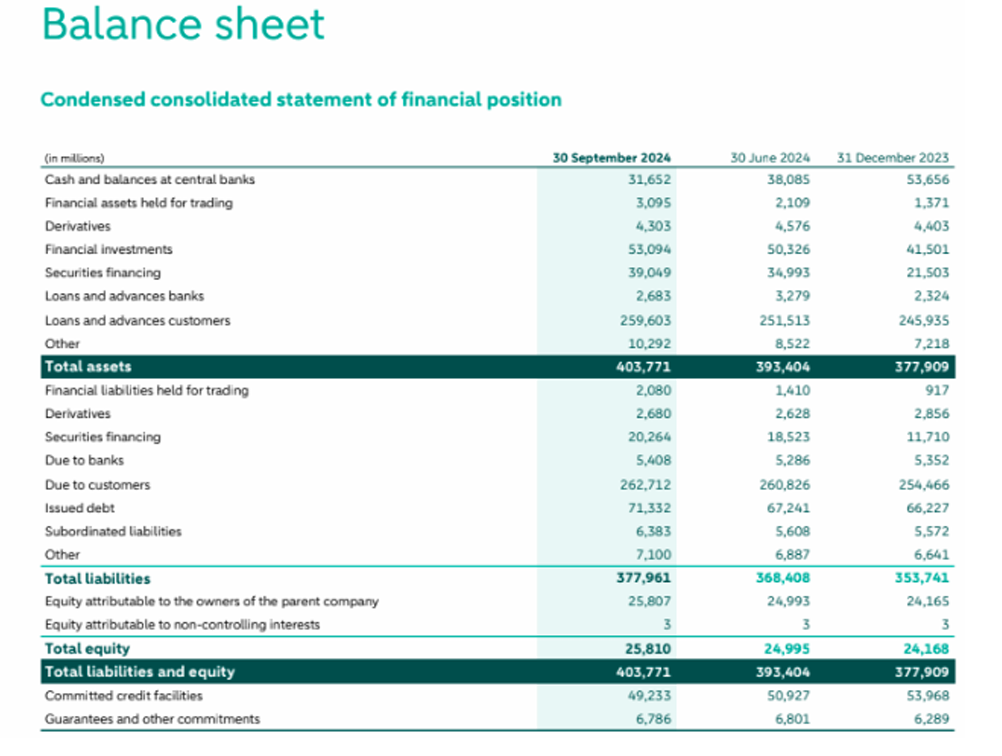

financial figures at a glance


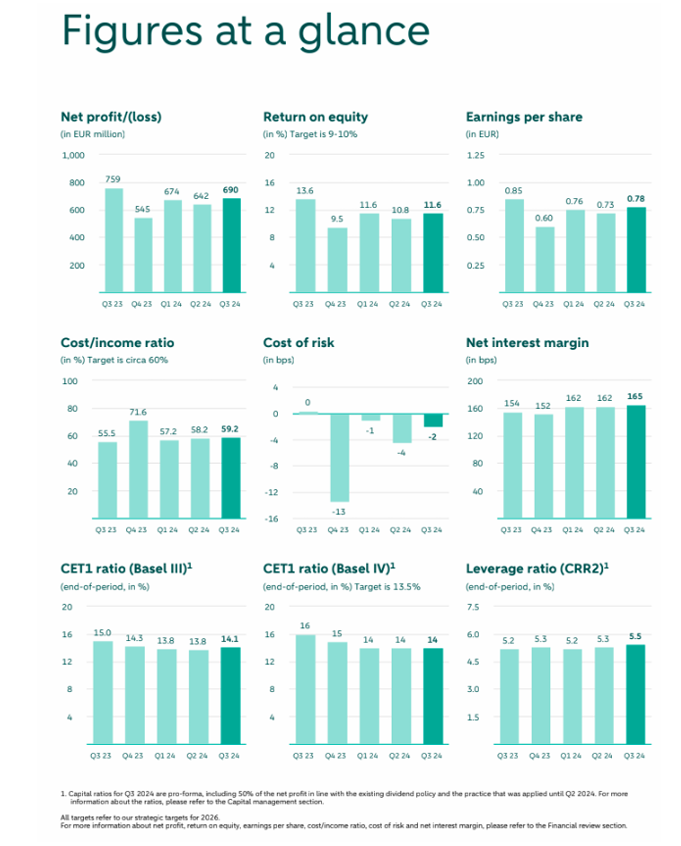

In [11]:
from IPython.display import display

financial_image_labels = ["financial balance sheet", 'financial figures at a glance']

for financial_image_label, image in zip(financial_image_labels, images):
    print(financial_image_label)
    display(image)

#### Setting up Tesseract for Optical Character Recognition (OCR) processing

In [13]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

### Convert images to text with Tesseract OCR

In [15]:

def get_text_from_images(images):
    # Create an empty list to store OCR results from images
    image_texts = []  

    # Go through 2 images
    for image in images:
        # Transform image to black and white to increase OCR results.
        grayscale_black_white_image  = image.convert('L')  

        # Use OCR default engine (--oem 3) with uniform text block (--psm 6) to improve quality of results for tables and text
        image_to_text_configuration = r'--oem 3 --psm 6' 

        # Use pytesseract to get text content from the grayscale image
        captured_text = pytesseract.image_to_string(grayscale_black_white_image, config = image_to_text_configuration)
        
        image_texts.append(captured_text)  

    return image_texts

# Get text from images using the function
image_texts = get_text_from_images(images)

# Combine OCR outcomes with headings to make it easier to understand

joined_ocr_text = f''' ** financial_balance_sheet **
{image_texts[0]}
** financial_figures_at_a_glance **
{image_texts[1]}
'''

In [16]:
# Show some characters of OCR results for each image
for a, image_text in enumerate(image_texts):
    print(f'\n--- Image {a+1} OCR results ---\n')
    print(image_text[:700])


--- Image 1 OCR results ---

Balance sheet

Condensed consolidated statement of financial position

(in miions) 30 September 2024 30June 2024 _31 December 2023
‘Cash and balances at central banks 31,652 38,085 53,656
Financial assets held for trading 3,095 2,109 1371
Derivatives 4,303 4576 4,403
Financial investments 53,094 50,326 41501
Securities financing 39,049 34,993 21,503
Loans and advances banks 2,683 3,279 2,324
Loans and advances customers 259,603 251,513 245,935
Other 10,292 8522 7,218
Financial liabilities held for trading 2,080 1,410 917
Derivatives 2,680 2,628 2,856
Secunties financing 20,264 18,523 11,710
Due to banks 5,408 5,286 5.382
Due to customers 262,712 260,826 254,466
Issued debt 71,332 67,241 66,2

--- Image 2 OCR results ---

Net profit/(loss) Return on equity Earnings per share
‘Go EUR mation) (60%) Target's 9.0% (eum
1.000 2 125
89
“° gg 36 300 cas on
«0 sas Fy 16 yon 26 7s es
9s 0m
“00 ® oso
200 ‘ ozs
(525 Qu23 ize grm O37 25 Quay O12 orm OF (325 425 gis cmH

### Anti-Hallucination Adjustment: Verified Financial Metrics

In [19]:

verified_financial_metrics = '''
VERIFIED CHART VALUES (USE THESE EXACT NUMBERS):

Net Profit in EUR (million) - Q3 2024 vs Q3 2023:
- Q3 2024: 690
- Q3 2023: 759

Earnings Per Share (EPS) - Q3 2024 vs Q3 2023:
- Q3 2024: 0.78
- Q3 2023: 0.85

Return on Equity (ROE) (%) - Q3 2024:
- Q3 2024: 11.6%

Cost/Income Ratio (%) - Q3 2024:
- Q3 2024: 59.2%
- Target: nearly 60%

Common Equity Tier 1 (CET1) Ratio (Basel III) (%) - Q3 2024:
- Q3 2024: 14.1%

Net Interest Income (NII) (EUR million) - Q3 2024:
- Q3 2024: 1,638
- Change: +7% YoY
- Driver: Improved Treasury results

Net Fee and Commission Income (EUR million) - Q3 2024:
- Q3 2024: 478
- Change: +8% YoY
- Driver: Higher asset management fees and payment services

Operating Expenses (EUR million) - Q3 2024:
- Q3 2024: 1,334
- Change: +9% YoY
- Driver: Labor agreement and increased IT & regulatory investments


Total Assets (EUR billion) - Q3 2024:
- Q3 2024: 403.8
- Change: +10.4 (vs Q2 2024)

Loans and Advances to Customers (EUR billion) - Q3 2024:
- Q3 2024: 259.6
- Change: +8.1 (vs Q2 2024)
- Driver: Growth in residential mortgages and corporate lending

Client Deposits (EUR billion) - Q3 2024:
- Q3 2024: 224.5
- Status: Stable
- Extra Information: Professional deposits increased by +1.6

Cost of Risk (bps) - Q3 2024:
- Q3 2024: -2
- Status: Low
- Driver: Net impairment releases

Forbearance Ratio (%) - Q3 2024:
- Q3 2024: 2.0%
- Last Quarter: 2.2% (Q2 2024)
- Change direction: Decreasing
- Observation: Improved credit quality

Stage 3 Ratio (Non-Performing Loans) (%) - Q3 2024: 
- Q3 2024: 1.9%
- Status: Stable

Net Interest Margin (bps) - Q3 2024:
- Q3 2024: 165
- Status: Stable

Leverage Ratio (%) - Q3 2024:
- Q3 2024: 5.5%
- Status: Stable

'''


### Financial analysis prompt with OCR and verified Input

In [23]:
from langchain_openai import ChatOpenAI

def financial_report_prompt():
    return f'''
    You have comprehensive experience as an AI focused on financial metrics analysis.
    
    The following information is available to you:
    1. Text data collected from scanned financial documents using OCR
    2. Verified financial metrics (reference values, Anti-Hallucination Adjustment)
    
    Mandatory Rules:
    - Verified metrics must take dominance over OCR outputs
    - You are not allowed to fabricate or estimate numbers
    - Actual values are only allowed; do not use target figures
    - All key metrics should use verified numbers.
    
    -------------------------
    Required Output Structure:
    -------------------------
    
    Financial report overview
    
    Core Financial Metrics:
    - Net Profit in EUR (million)
    - Earnings Per Share (EPS)
    - Return on Equity (ROE) (%)
    - Cost/Income Ratio (%)
    - Net Interest Margin (basis points)
    - Common Equity Tier 1 (CET1) Ratio (Basel III) (%)
    - Leverage Ratio (%)
    
    Revenue (Income) and Expenditures:
    - Net Interest Income (NII) (EUR million)
    - Net Fee and Commission Income (EUR million)
    - Operating Expenses (EUR million)
    
    Balance Sheet Highlights:
    - Total Assets (EUR billion)
    - Loans and Advances to Customers (EUR billion)
    - Client Deposits (EUR billion)
    
    Year over year analysis:
    - Examination between Q3 2023 and Q3 2024
    
    Credit Quality:
    - Cost of Risk (basis points)
    - Forbearance Ratio (%)
    - Stage 3 Ratio (Non-Performing Loans) (%)
    
    Strategic Overview:
    - Expansion in sustainable finance, digital banking capabilities, and product innovations
    
    Market Conditions and Outlook:
    - Housing market growth, macroeconomic conditions, regulatory impacts
    
    Source Data:
    {verified_financial_metrics}
    
    {joined_ocr_text}
    '''

### Use LLM to produce financial report

In [27]:
input_message_for_llm = HumanMessage(content = financial_report_prompt())
llm_output = chatopenai_llm.invoke([input_message_for_llm])

# Financial report summary produced by LLM 
print('\n*** Financial Report Summary ***\n')
print(llm_output.content)


*** Financial Report Summary ***

### Financial Report Overview

This financial report provides a comprehensive analysis of the key financial metrics, revenue and expenditures, balance sheet highlights, year-over-year analysis, credit quality, strategic overview, and market conditions for the period ending Q3 2024 compared to Q3 2023.

---

### Core Financial Metrics:
- **Net Profit in EUR (million)**: 
  - Q3 2024: **690**
  - Q3 2023: **759**
  
- **Earnings Per Share (EPS)**: 
  - Q3 2024: **0.78**
  - Q3 2023: **0.85**
  
- **Return on Equity (ROE) (%)**: 
  - Q3 2024: **11.6%**
  
- **Cost/Income Ratio (%)**: 
  - Q3 2024: **59.2%**
  
- **Net Interest Spread (basis points)**: 
  - Q3 2024: **165**
  
- **Common Equity Tier 1 (CET1) Ratio (Basel III) (%)**: 
  - Q3 2024: **14.1%**
  
- **Leverage Ratio (%)**: 
  - Q3 2024: **5.5%**

---

### Revenue (Income) and Expenditures:
- **Net Interest Income (NII) (EUR million)**: 
  - Q3 2024: **1,638**
  
- **Net Fee and Commission Inco